## Step 3: One Star, Up Close (Single-Target Exploration & Detrending Prototype)

Before scaling anything up, it helps to grab exactly *one* star and really look at it. This notebook is the exploratory sandbox — same spirit as the Kepler "check files" notebook, but built around `lightkurve`'s TESS-native API instead of raw `astropy.io.fits` wrangling. It's where the detrending and visualization approach gets prototyped before being folded into the full pipeline in `02_dataset_2.ipynb`.

**Context link:** There's a markdown cell linking to the [NASA Exoplanet Archive TOI table](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TOI) — a reminder that this exploration is meant to be cross-checked against known TESS Objects of Interest (candidate planets already flagged by the mission pipeline), useful for validating that your manual detection approach is actually finding real signals.

**The Algorithm:**
1. **Download one specific light curve** — hardcoded here as `TIC 25155310` — via `lightkurve.search_lightcurve(...).download()`. Notice this is *much* less code than the Kepler FITS-wrangling equivalent: `lightkurve` handles the download, HDU parsing, and column extraction all in one call, returning a ready-to-use `LightCurve` object.
2. **Convert to a Pandas DataFrame** with `.to_pandas()` — same "get it into a format I actually enjoy working with" move as the Kepler notebooks, except here `lightkurve` has already done most of the FITS-parsing heavy lifting for you.
3. **Normalize flux manually**: `(flux - mean) / std` — a plain z-score, applied directly on the DataFrame column rather than via `lightkurve`'s built-in `.normalize()` method (worth noting as a slight inconsistency vs. Notebook 2, which *does* use the built-in — same math, different route).
4. **Detrend with a rolling median** (`window=300, center=True, min_periods=10`), then `.bfill().ffill()` to patch the edges — this is the exact same rolling-median technique from the Kepler pipeline's exploration notebook, just with a slightly smaller window (300 vs. 400 cadences), reused here for a TESS light curve instead.
5. **Plot the raw flux over time** — a first visual gut-check before doing anything fancier.
6. **Plot a two-panel detrending summary**: normalized flux + trend line on top, detrended residual below with a zero reference line — letting you visually confirm the detrending actually flattened out the long-term drift.
7. **Zoom in on a known transit**: a hardcoded `transit_center = 1331.8` (in TESS BJD units) with a ±0.25 day window around it, isolating just that slice of the light curve in a scatter plot. This is the "does the dip actually look like a transit up close?" sanity check — the same visual QA step every candidate signal deserves before you get excited about it.

**Output:** Nothing saved to disk — this is a pure scratchpad notebook, same role as its Kepler counterpart. The value here is entirely in the *technique* (rolling-median detrending + zoomed transit inspection) that gets productionized in `02_dataset_2.ipynb`.

*In short: this is the "let's just look at ONE star really carefully before we industrialize this" notebook — the scientific equivalent of reading the whole recipe before turning on the stove.*

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
import lightkurve as lk
from lightkurve import search_lightcurve

In [3]:
lc = search_lightcurve("TIC 25155310", mission="TESS").download()

In [4]:
type(lc)

lightkurve.lightcurve.TessLightCurve

In [5]:
ll = lc.to_pandas()

In [6]:
ll.head(5)

,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,...,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
time,,,,,,,,,,,,,,,,,,,,,
1325.296626,9262.704102,12.471729,0.000898,70445,1623.851189,393.341453,8426.264648,11.040674,921.701477,3.190827,...,NaN,NaN,NaN,NaN,1623.851189,0.000890,393.341453,0.001001,0.029971,-0.066027
1325.298015,9271.197266,12.476470,0.000898,70446,1623.826405,393.313301,8449.153320,11.044871,923.711792,3.181095,...,NaN,NaN,NaN,NaN,1623.826405,0.000891,393.313301,0.000996,-0.000422,-0.100253
1325.299404,9290.672852,12.498974,0.000898,70447,1623.826744,393.309616,8466.763672,11.064793,923.746887,3.199772,...,NaN,NaN,NaN,NaN,1623.826744,0.000891,393.309616,0.000995,-0.001214,-0.103916
1325.300793,9262.817383,12.483087,0.000898,70448,1623.825748,393.300314,8442.092773,11.050729,925.656494,3.193503,...,NaN,NaN,NaN,NaN,1623.825748,0.000893,393.300314,0.000998,-0.002980,-0.115668
1325.302181,9277.713867,12.492529,0.000898,70449,1623.817503,393.300172,8457.203125,11.059088,929.607605,3.195225,...,NaN,NaN,NaN,NaN,1623.817503,0.000894,393.300172,0.000996,-0.009857,-0.115354


In [7]:
ll["brightness_norm"] = (ll["flux"] - ll["flux"].mean()) / ll["flux"].std()

In [8]:
window = 300
trend = ll["brightness_norm"].rolling(window, center=True, min_periods=10).median()

In [9]:
trend = trend.bfill().ffill()

In [10]:
ll["detrended"] = ll["brightness_norm"] - trend

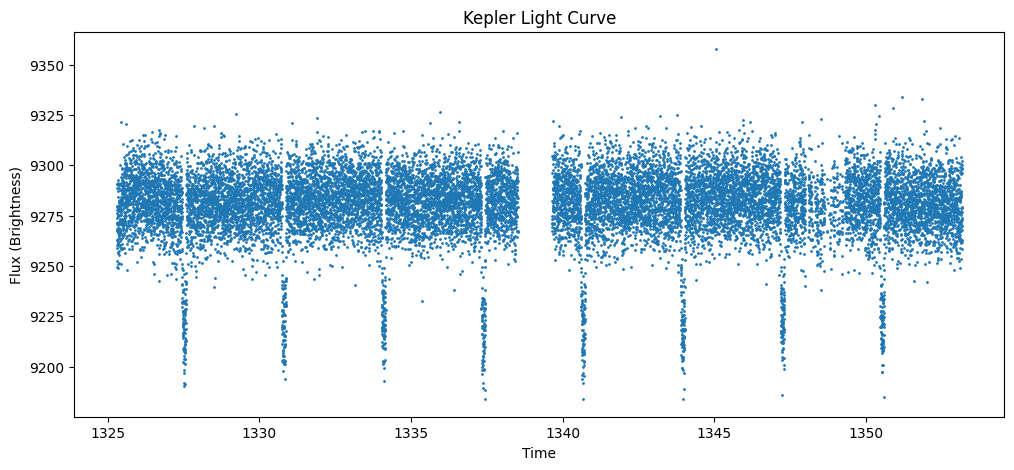

In [11]:
plt.figure(figsize=(12,5))
plt.plot(ll.index, ll['flux'], '.', markersize=2)
plt.xlabel("Time")
plt.ylabel("Flux (Brightness)")
plt.title("Kepler Light Curve")
plt.show()

In [12]:
ll.index.name

'time'

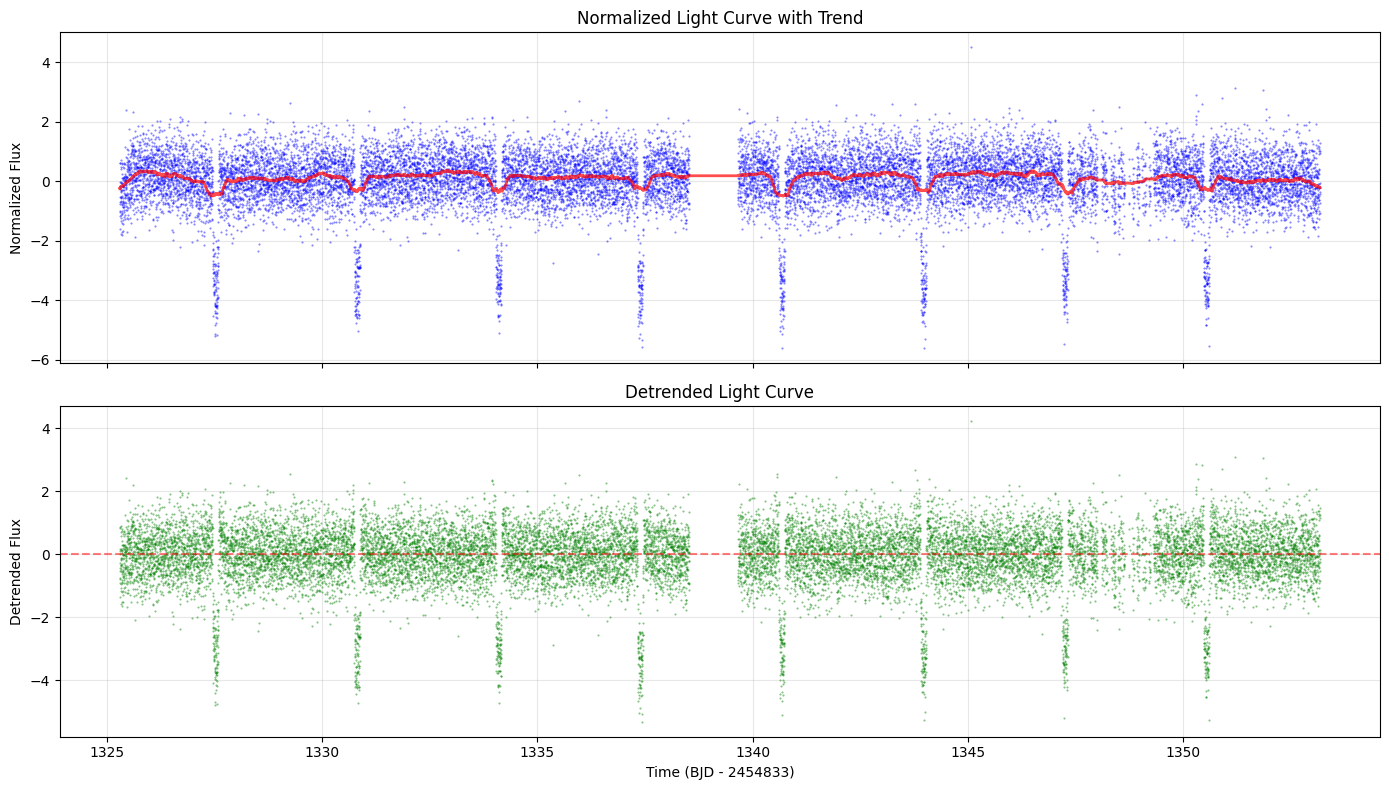

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ll.index, ll['brightness_norm'], '.', markersize=1, alpha=0.5, color='blue')
axes[0].plot(ll.index, trend, '-', linewidth=2, color='red', alpha=0.7)
axes[0].set_ylabel("Normalized Flux")
axes[0].set_title("Normalized Light Curve with Trend")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ll.index, ll['detrended'], '.', markersize=1, alpha=0.5, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Time (BJD - 2454833)")
axes[1].set_ylabel("Detrended Flux")
axes[1].set_title("Detrended Light Curve")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

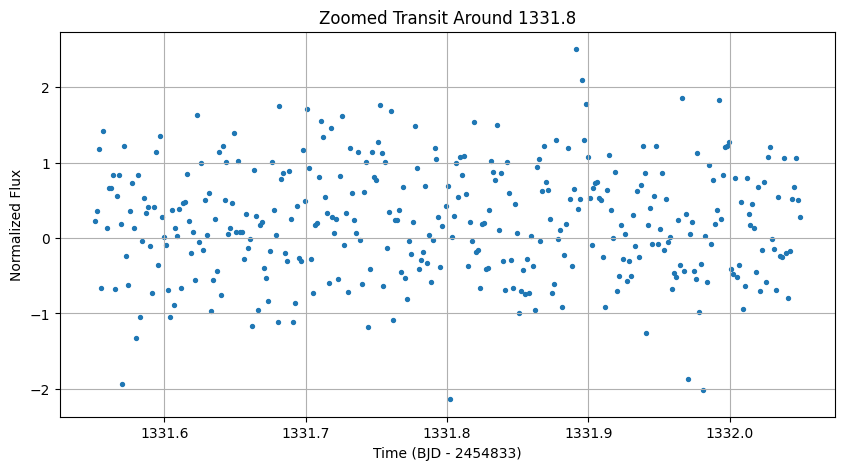

In [14]:
transit_center = 1331.8

# Show ±0.25 days around it
mask = (ll.index > transit_center - 0.25) & (ll.index < transit_center + 0.25)

plt.figure(figsize=(10,5))
plt.scatter(ll.index[mask], ll.brightness_norm[mask], s=8)
plt.xlabel("Time (BJD - 2454833)")
plt.ylabel("Normalized Flux")
plt.title(f"Zoomed Transit Around {transit_center}")
plt.grid(True)
plt.show()